# Instalasi library yang dibutuhkan

In [ ]:
!pip install requests beautifulsoup4 pandas lxml -q

# Kode Utama

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import logging
import re
from datetime import datetime

GUEST_SEARCH  = "https://www.linkedin.com/jobs-guest/jobs/api/seeMoreJobPostings/search"
DETAIL_BASE   = "https://id.linkedin.com/jobs/view/{}"   # pakai subdomain id.
JOBS_PER_PAGE = 25
DELAY_MIN, DELAY_MAX = 3, 6

HEADERS_SEARCH = {
    "User-Agent"     : "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept-Language": "id-ID,id;q=0.9,en-US;q=0.8",
    "Accept"         : "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Referer"        : "https://www.linkedin.com/jobs/",
    "Connection"     : "keep-alive",
}

# Header lebih lengkap untuk detail page — meniru browser sungguhan
HEADERS_DETAIL = {
    "User-Agent"                : "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept"                    : "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8",
    "Accept-Language"           : "id-ID,id;q=0.9,en-US;q=0.8,en;q=0.7",
    "Accept-Encoding"           : "gzip, deflate, br",
    "Connection"                : "keep-alive",
    "Upgrade-Insecure-Requests" : "1",
    "Sec-Fetch-Dest"            : "document",
    "Sec-Fetch-Mode"            : "navigate",
    "Sec-Fetch-Site"            : "same-origin",
    "Sec-Fetch-User"            : "?1",
    "Sec-CH-UA"                 : '"Not_A Brand";v="8", "Chromium";v="120", "Google Chrome";v="120"',
    "Sec-CH-UA-Mobile"          : "?0",
    "Sec-CH-UA-Platform"        : '"Windows"',
    "Cache-Control"             : "max-age=0",
}

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s",
                    handlers=[logging.FileHandler("scraping_linkedin.log"), logging.StreamHandler()])
log = logging.getLogger(__name__)

def make_session():
    s = requests.Session()
    s.headers.update(HEADERS_SEARCH)
    try:
        # Kunjungi homepage dulu agar dapat cookie JSESSIONID, bcookie, dll.
        s.get("https://www.linkedin.com/", timeout=10)
        time.sleep(random.uniform(1.5, 3))
        # Kunjungi halaman jobs untuk dapat cookie tambahan
        s.get("https://www.linkedin.com/jobs/", timeout=10)
        time.sleep(random.uniform(1, 2))
    except Exception:
        pass
    return s

def safe_get(session, url, params=None, headers_override=None, retries=3):
    for attempt in range(1, retries + 1):
        try:
            h    = headers_override or {}
            resp = session.get(url, params=params, headers=h, timeout=15)
            if resp.status_code == 429:
                wait = 30 * attempt
                log.warning(f"  Rate limited. Tunggu {wait}s...")
                time.sleep(wait)
                continue
            if resp.status_code == 200:
                return BeautifulSoup(resp.text, "lxml")
            log.warning(f"  HTTP {resp.status_code} attempt {attempt} → {url[:70]}")
            time.sleep(5 * attempt)
        except requests.RequestException as e:
            log.warning(f"  Request error attempt {attempt}: {e}")
            time.sleep(5 * attempt)
    return None

def clean(text):
    return " ".join(str(text or "").strip().split())

def get_job_cards(session, keyword, location, start=0):
    params = {"keywords": keyword, "location": location,
              "start": start, "f_TPR": "r2592000", "sortBy": "DD"}
    soup = safe_get(session, GUEST_SEARCH, params=params)
    if soup is None:
        return []

    cards = soup.select("div.base-card, div.job-search-card, li[data-occludable-job-id]")
    log.info(f"    {len(cards)} card (start={start})")

    results = []
    for card in cards:
        raw_id   = card.get("data-entity-urn","") or card.get("data-job-id","") or card.get("data-occludable-job-id","")
        id_match = re.search(r"(\d{7,})", raw_id)
        job_id   = id_match.group(1) if id_match else ""

        link = card.select_one("a.base-card__full-link, a[href*='/jobs/view/']")
        url  = link.get("href","").split("?")[0] if link else ""
        if not url and job_id:
            url = f"https://www.linkedin.com/jobs/view/{job_id}/"
        if not url:
            continue
        if not url.startswith("http"):
            url = "https://www.linkedin.com" + url

        time_el = card.select_one("time")
        results.append({
            "job_id"     : job_id,
            "source_url" : url,
            "posted_date": time_el.get("datetime","") if time_el else "",
            # Data parsial dari card
            "job_title"   : clean(card.select_one("h3.base-search-card__title, h3[class*='title']").get_text()) if card.select_one("h3.base-search-card__title, h3[class*='title']") else "",
            "company_name": clean(card.select_one("h4.base-search-card__subtitle, a.hidden-nested-link").get_text()) if card.select_one("h4.base-search-card__subtitle, a.hidden-nested-link") else "",
            "location"    : clean(card.select_one("span.job-search-card__location").get_text()) if card.select_one("span.job-search-card__location") else "",
        })
    return results

def scrape_detail(session, item):
    """
    Ambil detail via id.linkedin.com dengan header browser-like penuh.
    Jika gagal, kembalikan data parsial dari list page.
    """
    job_id = item.get("job_id","")
    url    = DETAIL_BASE.format(job_id) if job_id else item["source_url"]

    # Set referer seolah user klik dari halaman search
    HEADERS_DETAIL["Referer"] = "https://www.linkedin.com/jobs/search/"

    soup = safe_get(session, url, headers_override=HEADERS_DETAIL)

    if soup is None:
        log.warning(f"  Detail gagal, pakai data parsial: {url[:60]}")
        return {
            **item,
            "job_type": "", "experience_level": "", "education_req": "",
            "salary_range": "Tidak Dicantumkan", "job_requirements": "",
            "job_responsibilities": "", "industries": "", "job_function": "",
            "applicant_count": "", "source_platform": "LinkedIn",
            "scraped_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        }

    # ── Atribut utama ──
    title_el   = soup.select_one("h1.top-card-layout__title, h1.topcard__title, h1")
    company_el = soup.select_one("a.topcard__org-name-link, .topcard__flavor:not(.topcard__flavor--bullet)")
    loc_el     = soup.select_one(".topcard__flavor--bullet, span[class*='location']")

    # ── Criteria list ──
    criteria = {}
    for li in soup.select("li.description__job-criteria-item"):
        h = li.select_one("h3")
        v = li.select_one("span.description__job-criteria-text")
        if h and v:
            criteria[clean(h.get_text()).lower()] = clean(v.get_text())

    def find_c(*keys):
        for k in keys:
            for ck, cv in criteria.items():
                if k in ck: return cv
        return ""

    # ── Deskripsi ──
    desc_el   = soup.select_one("div.description__text, div.show-more-less-html__markup")
    desc_text = clean(desc_el.get_text("\n")) if desc_el else ""

    def extract_section(keywords):
        lower = desc_text.lower()
        for kw in keywords:
            idx = lower.find(kw)
            if idx != -1:
                return clean(desc_text[idx: idx + 800])
        return desc_text[:500]

    # ── Salary ──
    salary_el  = soup.select_one("div[class*='salary'], .compensation__salary")
    salary_raw = clean(salary_el.get_text()) if salary_el else ""
    if not salary_raw:
        m = re.search(r"(Rp\.?\s?[\d.,]+\s?(?:–|-)\s?Rp\.?\s?[\d.,]+|IDR\s?[\d,.]+(?:\s?[-–]\s?IDR\s?[\d,.]+)?)", desc_text, re.IGNORECASE)
        salary_raw = m.group(0).strip() if m else "Tidak Dicantumkan"

    # ── Applicant count ──
    app_el  = soup.select_one("span.num-applicants__caption, figcaption.num-applicants__caption, span[class*='applicant']")
    app_raw = clean(app_el.get_text()) if app_el else ""
    app_num = re.search(r"(\d[\d,]*)", app_raw)
    applicant_count = app_num.group(1).replace(",","") if app_num else ""

    return {
        "job_title"            : clean(title_el.get_text())   if title_el   else item.get("job_title",""),
        "company_name"         : clean(company_el.get_text()) if company_el else item.get("company_name",""),
        "location"             : clean(loc_el.get_text())     if loc_el     else item.get("location",""),
        "job_type"             : find_c("employment type","tipe pekerjaan"),
        "experience_level"     : find_c("seniority level","tingkat senioritas"),
        "education_req"        : find_c("education","pendidikan"),
        "salary_range"         : salary_raw,
        "job_requirements"     : extract_section(["qualification","requirement","kualifikasi","persyaratan"]),
        "job_responsibilities" : extract_section(["responsibilities","tanggung jawab","tugas"]),
        "industries"           : find_c("industries","industri"),
        "job_function"         : find_c("job function","fungsi pekerjaan"),
        "applicant_count"      : applicant_count,
        "posted_date"          : item.get("posted_date",""),
        "source_platform"      : "LinkedIn",
        "source_url"           : item["source_url"],
        "scraped_at"           : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    }

def run_scraper(keywords, locations, max_pages=2,
                output_csv="raw_jobs_linkedin.csv", output_json="raw_jobs_linkedin.json"):
    session   = make_session()
    all_jobs  = []
    seen_urls = set()

    try:
        for keyword in keywords:
            for location in locations:
                log.info(f"\n{'='*55}\n  Keyword: '{keyword}'  |  Lokasi: '{location}'\n{'='*55}")
                for page in range(max_pages):
                    cards = get_job_cards(session, keyword, location, page * JOBS_PER_PAGE)
                    if not cards:
                        break
                    for item in cards:
                        if item["source_url"] in seen_urls:
                            continue
                        seen_urls.add(item["source_url"])

                        log.info(f"  Detail ({item['job_id']}): {item['job_title'][:50]}")
                        record = scrape_detail(session, item)
                        all_jobs.append(record)
                        log.info(f"    ✓ jenis: {record.get('job_type','-')} | exp: {record.get('experience_level','-')}")
                        time.sleep(random.uniform(DELAY_MIN, DELAY_MAX))
                    time.sleep(random.uniform(2, 3))

    except KeyboardInterrupt:
        log.info("Dihentikan. Menyimpan data sejauh ini...")

    df = pd.DataFrame(all_jobs)
    if df.empty:
        log.warning("Tidak ada data terkumpul.")
        return df

    df.drop_duplicates(subset=["job_title","company_name","location"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    df.to_csv(output_csv,   index=False, encoding="utf-8-sig")
    df.to_json(output_json, orient="records", indent=2, force_ascii=False)
    log.info(f"\n✅ Selesai! {len(df)} lowongan tersimpan → {output_csv}")
    return df

# Pemanggilan Functions

## Pemanggilan function run_scraper() untuk memulai scraping

In [ ]:
df = run_scraper(
    keywords=["Data", "Backend", "Software", "AI", "Developer"],
    locations=["Jakarta, Indonesia","Surabaya, Jawa Timur, Indonesia"],
    max_pages=2
)

# Pengecekan dataset dengan pandas

## Mengecek dimensi dari dataset

In [ ]:
df.shape

(144, 16)

## Mengecek tail (rows terbawah) dan head (rows teratas) dataset untuk melihat beberapa sample dari dataset

In [ ]:
df.tail(10)

,job_title,company_name,location,job_type,experience_level,education_req,salary_range,job_requirements,job_responsibilities,industries,job_function,applicant_count,posted_date,source_platform,source_url,scraped_at
134,Quality Engineer,PT. Indosat Tbk,"Jakarta Raya, Indonesia",,Tingkat pemula,,Tidak Dicantumkan,requirements for testability and risk Design a...,About The Role We’re looking for a passionate ...,Telekomunikasi,Jaminan Kualitas,,2026-02-20,LinkedIn,https://id.linkedin.com/jobs/view/quality-engi...,2026-03-04 19:02:55
135,Junior Developer Java dan .Net,PT. Adi Data Informatika,Area DKI Jakarta,,Tingkat pemula,,Tidak Dicantumkan,Qualifications Junior Developer (Java & .Net) ...,Java Developer Technical Skills (Basic Level) ...,Jasa TI dan Konsultan TI,"Rekayasa, Teknologi Informasi",57,2026-02-10,LinkedIn,https://id.linkedin.com/jobs/view/junior-devel...,2026-03-04 19:03:02
136,Software Engineer,Ninja Xpress,Jakarta,,Tingkat pemula,,Tidak Dicantumkan,Requirements Minimum 2+ years of industry expe...,Responsibilities Proficient in English both wr...,"Transportasi, Logistik, Rantai Pasokan, dan Pe...","Rekayasa, Teknologi Informasi",,2026-02-26,LinkedIn,https://id.linkedin.com/jobs/view/software-eng...,2026-03-04 19:03:08
137,Software Engineer (On-site),Integrity Malaysia,Jakarta,,Senior tingkat menengah,,Tidak Dicantumkan,qualifications who enjoy the challenge to grow...,We’re looking for a passionate and experienced...,Konsultan dan Jasa Bisnis,"Rekayasa, Teknologi Informasi",,2026-02-04,LinkedIn,https://id.linkedin.com/jobs/view/software-eng...,2026-03-04 19:03:13
138,Software Engineer,OCBC Indonesia,Kota Tangerang,,Senior tingkat menengah,,Tidak Dicantumkan,Requirements: Demonstrate a minimum of 5 years...,Responsibilities: Bring your coding expertise ...,"Perbankan, Jasa TI dan Konsultan TI, Teknologi...","Teknologi Informasi, Rekayasa",,2026-03-03,LinkedIn,https://id.linkedin.com/jobs/view/software-eng...,2026-03-04 19:03:19
139,Front End Engineer (Credit) - Sea Labs,Monee,"Jakarta Raya, Indonesia",,Tingkat pemula,,Tidak Dicantumkan,requirements and UI/UX designs into high-quali...,"About The Team Monee is a part of Sea Group, a...",Jasa Keuangan,"Rekayasa, Teknologi Informasi",,2026-02-12,LinkedIn,https://id.linkedin.com/jobs/view/front-end-en...,2026-03-04 19:03:24
140,"Software Engineer (Surabaya, Indonesia)",camLine | Elisa Industriq,Surabaya,,Tingkat pemula,,Tidak Dicantumkan,"requirements analysis to design, coding, testi...",Responsibilities Include But Not Limited To: I...,Pengembangan Perangkat Lunak,"Rekayasa, Teknologi Informasi",,2026-02-12,LinkedIn,https://id.linkedin.com/jobs/view/software-eng...,2026-03-04 19:03:31
141,WEB DEVELOPER - INTERNSHIP,PT Tiga Berlian Mandiri (Tiberman),Wonokromo,,Tidak Berlaku,,"Rentang gaji pokok Rp 1.000.000,00/bln - Rp 1....",Kualifikasi Mahasiswa aktif jurusan Teknik Inf...,tanggung jawab Bersedia menjalani masa interns...,Grosir Impor dan Ekspor,"Rekayasa, Teknologi Informasi",,2026-03-04,LinkedIn,https://id.linkedin.com/jobs/view/web-develope...,2026-03-04 19:03:36
142,Fullstack Javascript Developer,Relove,Surabaya,,Tingkat pemula,,Tidak Dicantumkan,Kualifikasi Wajib berdomisili di Surabaya. Pen...,"tanggung jawab mengembangkan, memelihara, dan ...",Ritel Pakaian dan Busana,"Rekayasa, Teknologi Informasi",,2026-03-04,LinkedIn,https://id.linkedin.com/jobs/view/fullstack-ja...,2026-03-04 19:03:42
143,Manual Quality Assurance,WidaTech,Surabaya,,Tingkat pemula,,"Rentang gaji pokok Rp 2.000.000,00/bln - Rp 2....",requirement Melakukan exploratory testing untu...,Responsibilities ✅ Responsibilities Melakukan ...,Jasa TI dan Konsultan TI,Jaminan Kualitas,41,2026-02-25,LinkedIn,https://id.linkedin.com/jobs/view/manual-quali...,2026-03-04 19:03:48


In [ ]:
df.head(10)

,job_title,company_name,location,job_type,experience_level,education_req,salary_range,job_requirements,job_responsibilities,industries,job_function,applicant_count,posted_date,source_platform,source_url,scraped_at
0,Process Development Internship,Kalbe Nutritionals (PT Sanghiang Perkasa),Jakarta Timur,,Magang,,Tidak Dicantumkan,Requirements Kualifikasi Siswa dari SMK Jurusa...,Responsibilities Aktifitas Pembelajaran: Memba...,Jasa Penyedia Makanan dan Minuman,"Manajemen, Manufaktur",73,2026-03-02,LinkedIn,https://id.linkedin.com/jobs/view/process-deve...,2026-03-04 18:50:27
1,Business Finance & Analytics Officer,PT. Sarimelati Kencana Tbk.,"Jakarta Raya, Indonesia",,Senior tingkat menengah,,Tidak Dicantumkan,Requirements: Min S1/ Bachelor's degree in Fin...,Responsibilities: Financial Analysis: provide ...,"Restoran, Jasa Keuangan","Keuangan, Analis, Akuntansi/Audit",,2026-02-11,LinkedIn,https://id.linkedin.com/jobs/view/business-fin...,2026-03-04 18:50:33
2,Auditor,PT Bank Mandiri (Persero) Tbk.,"Jakarta Raya, Indonesia",,Senior tingkat menengah,,Tidak Dicantumkan,Requirements Pendidikan minimal S1/setara. Pen...,tugas dan standar profesi. Melaksanakan penuga...,Perbankan,Akuntansi/Audit,,2026-02-23,LinkedIn,https://id.linkedin.com/jobs/view/auditor-at-p...,2026-03-04 18:50:37
3,Staff-Collection & Reconcile HBB,PT. Indosat Tbk,"Jakarta Raya, Indonesia",,Senior tingkat menengah,,Tidak Dicantumkan,Qualification Proven experience as Collection ...,Responsibilities: Collection & Reconcile Manag...,Telekomunikasi,"Akuntansi/Audit, Keuangan",,2026-02-25,LinkedIn,https://id.linkedin.com/jobs/view/staff-collec...,2026-03-04 18:50:42
4,"Data Analyst, Business Intelligence",Shopee,"Jakarta Raya, Indonesia",,Tingkat pemula,,Tidak Dicantumkan,Requirements Master's or Bachelor's degree in ...,Job Description Assist the various business un...,"Platform Marketplace Internet, Teknologi, Info...","Strategi/Perencanaan, Analis, Konsultasi",,2026-03-02,LinkedIn,https://id.linkedin.com/jobs/view/data-analyst...,2026-03-04 18:50:48
5,Finance Accounting,LG Sinar Mas,Area DKI Jakarta,,Asosiasi,,Tidak Dicantumkan,Qualifications Bachelor’s degree in accounting...,Responsibilities Manage and verify supplier in...,"Jasa TI dan Konsultan TI, Konsultan dan Jasa B...",Keuangan,,2026-02-24,LinkedIn,https://id.linkedin.com/jobs/view/finance-acco...,2026-03-04 18:50:53
6,Business Analyst,OTO,Jakarta Barat,,Senior tingkat menengah,,Tidak Dicantumkan,Requirements: Bachelor's Degree in Engineering...,"Responsibilities: Responsible for collecting, ...","Manufaktur Kendaraan Bermotor, Jasa Keuangan","Analis, Manajemen Proyek, Bisnis Umum",,2026-03-03,LinkedIn,https://id.linkedin.com/jobs/view/business-ana...,2026-03-04 18:50:59
7,Sales & Financial Business Analyst,PT Bank Sinarmas Tbk,Jakarta Barat,,Asosiasi,,Tidak Dicantumkan,Requirements Pendidikan min. S1 Finance / Akun...,Requirements Pendidikan min. S1 Finance / Akun...,Perbankan,"Akuntansi/Audit, Keuangan, Analis",,2026-02-20,LinkedIn,https://id.linkedin.com/jobs/view/sales-financ...,2026-03-04 18:51:05
8,Experience Transformation Analyst,PT. Indosat Tbk,"Jakarta Raya, Indonesia",,Senior tingkat menengah,,Tidak Dicantumkan,Requirements: Bachelor’s degree in business ad...,Responsibilities: Document and update end-to-e...,"Telekomunikasi, Platform Marketplace Internet,...","Pengembangan Bisnis, Riset, Pemasaran",,2026-02-10,LinkedIn,https://id.linkedin.com/jobs/view/experience-t...,2026-03-04 18:51:11
9,Consumer Insights & Marketing Intelligence Sta...,Lemonilo,"Jakarta Raya, Indonesia",,Tingkat pemula,,Tidak Dicantumkan,"As a Marketing Team , you will be responsible ...","As a Marketing Team , you will be responsible ...","Jasa Kesejahteraan dan Kebugaran, Manufaktur M...","Analis, Pemasaran, Riset",,2026-02-25,LinkedIn,https://id.linkedin.com/jobs/view/consumer-ins...,2026-03-04 18:51:16


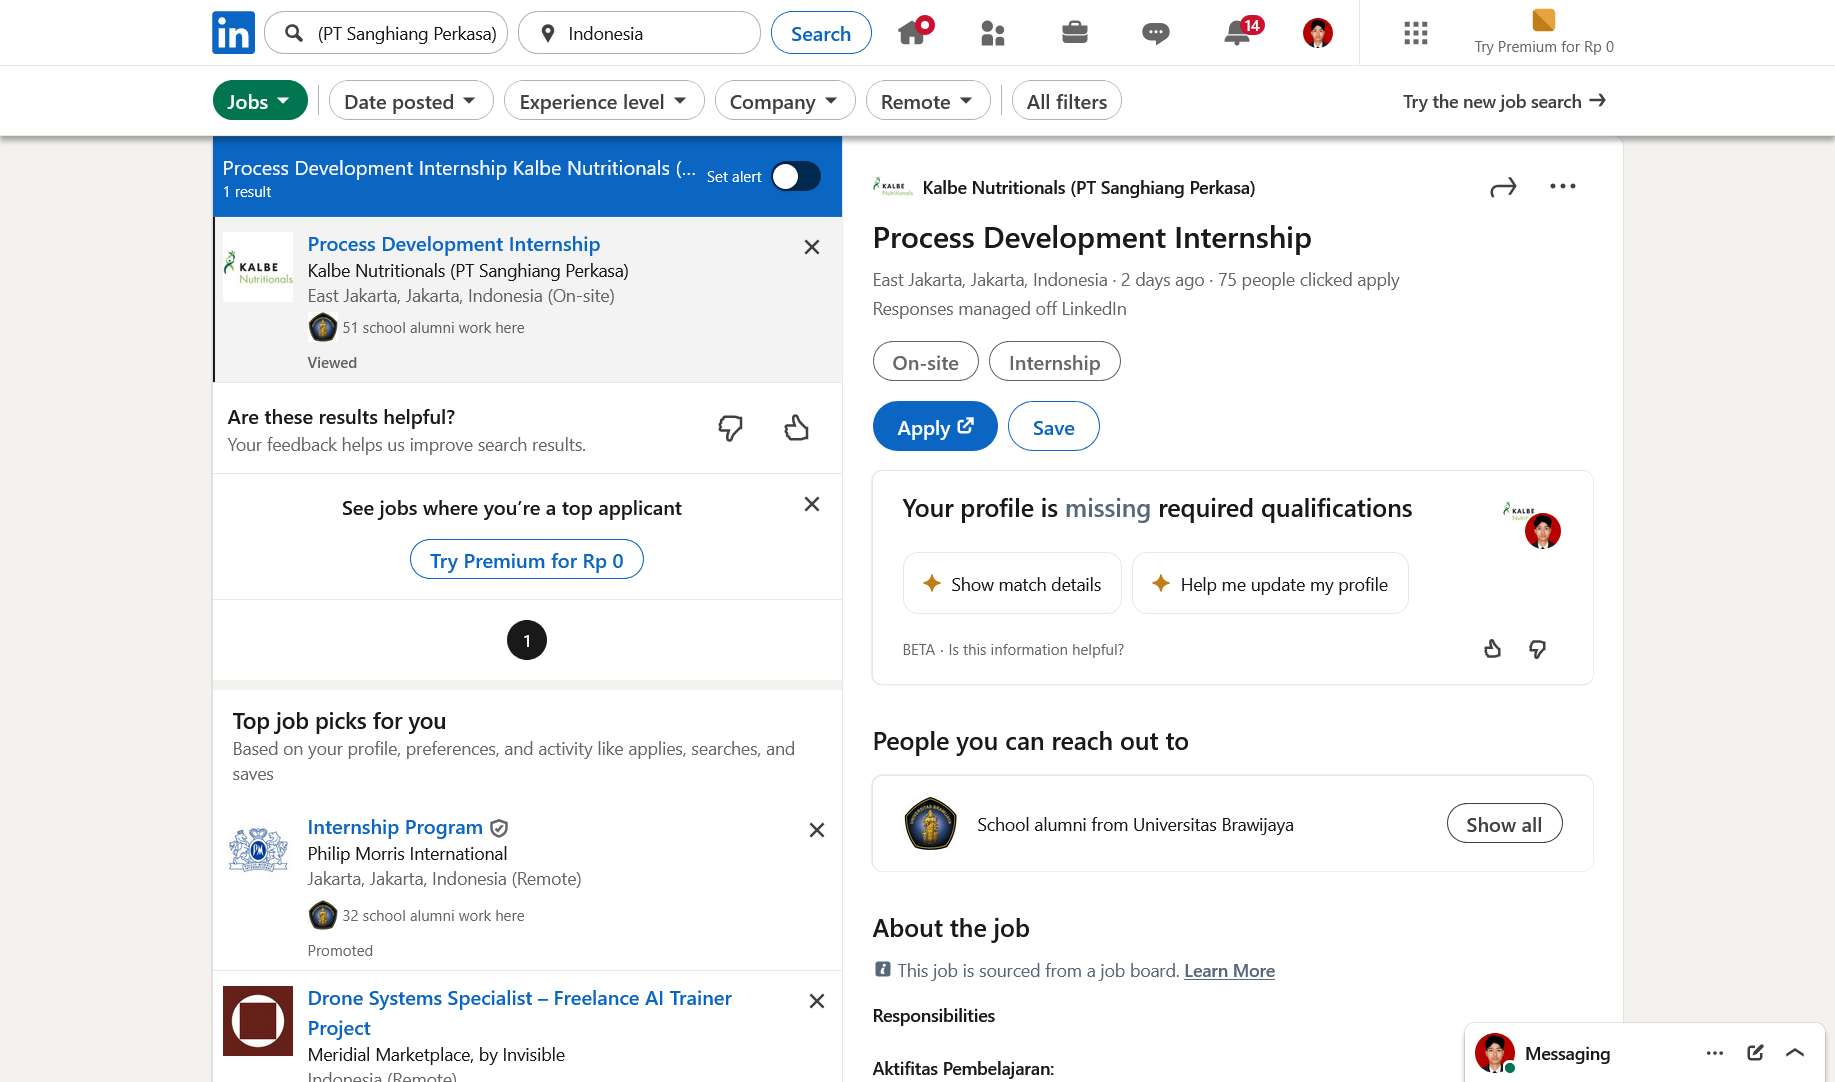

Validasi hasil scraping dengan mencari job offering secara manual

## Melihat informasi dataset dengan .describe() dan .info() untuk mengecek deskripsi serta data type dari dataset

In [ ]:
df.describe()

,job_title,company_name,location,job_type,experience_level,education_req,salary_range,job_requirements,job_responsibilities,industries,job_function,applicant_count,posted_date,source_platform,source_url,scraped_at
count,144,144,144,144,144,144,144,144,144,144,144,144,144,144,144,144
unique,133,88,17,1,7,1,10,144,142,56,43,37,27,1,144,144
top,Back End Developer,Meratus Group,Surabaya,,Tingkat pemula,,Tidak Dicantumkan,Requirements Kualifikasi Siswa dari SMK Jurusa...,Company Description About Grab and Our Workpla...,Jasa TI dan Konsultan TI,"Rekayasa, Teknologi Informasi",,2026-03-04,LinkedIn,https://id.linkedin.com/jobs/view/process-deve...,2026-03-04 18:50:27
freq,4,11,42,144,69,144,135,1,2,20,41,101,21,144,1,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_title             144 non-null    object
 1   company_name          144 non-null    object
 2   location              144 non-null    object
 3   job_type              144 non-null    object
 4   experience_level      144 non-null    object
 5   education_req         144 non-null    object
 6   salary_range          144 non-null    object
 7   job_requirements      144 non-null    object
 8   job_responsibilities  144 non-null    object
 9   industries            144 non-null    object
 10  job_function          144 non-null    object
 11  applicant_count       144 non-null    object
 12  posted_date           144 non-null    object
 13  source_platform       144 non-null    object
 14  source_url            144 non-null    object
 15  scraped_at            144 non-null    ob

## Mengecek jumlah null dan duplicates dalam dataset (Tidak ditemukan null maupun duplicates, sehingga tidak dilakukan drop pada rows maupun imputasi values)

In [ ]:
df.isnull().sum()

,0
job_title,0
company_name,0
location,0
job_type,0
experience_level,0
education_req,0
salary_range,0
job_requirements,0
job_responsibilities,0
industries,0


In [ ]:
df.duplicated().sum()

np.int64(0)

## Mengecek banyaknya unique values tiap feature

In [ ]:
df.nunique()

,0
job_title,133
company_name,88
location,17
job_type,1
experience_level,7
education_req,1
salary_range,10
job_requirements,144
job_responsibilities,142
industries,56


## Melihat .head() sebaran jumlah untuk setiap value dalam feature

In [ ]:
df['job_title'].value_counts().head(20)

,count
job_title,
Back End Developer,4
Software Engineer,3
International Management Trainee,2
Business Analyst,2
Junior Software Engineer,2
AI Engineer,2
Fullstack Developer,2
SAMPOERNA ACADEMY - CAMPUS PRINCIPAL (ELC-G3) SURABAYA PI,2
"Data Analyst, Business Intelligence",1


In [ ]:
df['company_name'].value_counts().head(20)

,count
company_name,
Meratus Group,11
PT. Indosat Tbk,10
PT Astra International Tbk,6
Shopee,4
OCBC Indonesia,3
WidaTech,3
Sea,3
TalentPop App,3
"PT. Erajaya Swasembada, Tbk.",3


In [ ]:
df['location'].value_counts().head(20)

,count
location,
Surabaya,42
"Jakarta Raya, Indonesia",30
Jakarta,29
Surabaya dan Sekitarnya,10
Area DKI Jakarta,8
Kota Tangerang,6
Jakarta Selatan,5
Wonokromo,3
Jakarta Timur,2


In [ ]:
df['job_type'].value_counts()

,count
job_type,
,144


In [ ]:
df['experience_level'].value_counts()

,count
experience_level,
Tingkat pemula,69
Senior tingkat menengah,40
Asosiasi,21
Tidak Berlaku,6
Magang,5
Direktur,2
Eksekutif,1


In [ ]:
df['education_req'].value_counts()

,count
education_req,
,144


In [ ]:
df['salary_range'].value_counts()

,count
salary_range,
Tidak Dicantumkan,135
IDR 18.500.000,1
Rp 6.000.000 – Rp 8.000.000,1
"Rentang gaji pokok Rp 4.500.000,00/bln - Rp 4.500.001,00/bln",1
"Rentang gaji pokok Rp 8.500.000,00/bln - Rp 10.000.000,00/bln",1
"Rentang gaji pokok Rp 2.800.000,00/bln - Rp 4.000.000,00/bln",1
"Rentang gaji pokok Rp 2.800.000,00/bln - Rp 4.200.000,00/bln",1
"Rentang gaji pokok Rp 3.500.000,00/bln - Rp 3.500.001,00/bln",1
"Rentang gaji pokok Rp 1.000.000,00/bln - Rp 1.500.000,00/bln",1


In [ ]:
df['job_requirements'].value_counts().head(20)

,count
job_requirements,
Requirements Kualifikasi Siswa dari SMK Jurusan Analisa Kimia Mahasiswa minimal semester 6 yang sedang dalam terbuka untuk mengikuti Program Magang Memahami proses uji sampel makanan di laboratorium Teliti dan memiliki analisa masalah yang baik Bersedia mengikuti program Magang selama 6 bulan. Periode Program Magang dari bulan Maret - September 2026 Show more Show less,1
"Requirements: Min S1/ Bachelor's degree in Finance, Accounting, Business, or related field. Strong analytical with attention to detail. Proficiency in budgeting, financial modeling and data analysis. Knowledge of accounting principles and financial reporting. Excellent communication and presentation skills. Advanced proficiency in Microsoft Excel and other relevant financial software. Experience in creating dashboards with Google Data Studio/Looker is preferable. Show more Show less",1
Requirements Pendidikan minimal S1/setara. Pengalaman minimal 4 tahun sebagai Auditor di Banking Industry. Memiliki pengetahuan terkait produk kredit. Show more Show less,1
"Qualification Proven experience as Collection and Payment specialist or similar role Knowledge of billing procedures and collection techniques (e.g. skip tracing) Familiarity with laws related to debt collection (e.g. FDCPA) Working knowledge of MS Office and databases Comfortable working with targets Patience and ability to manage stress Ability to think strategically and to lead Related Experience At least 3 years' experience as a collection expert, or a similar customer support role. Proven track record of managing all aspects of a successful product throughout its lifecycle Proven ability to solve issue on billing and payment Background in collection and payments activities Strong problem solving skills and willingness to roll up one's sleeves to get the job Skilled at working effectiv",1
"Requirements Master's or Bachelor's degree in quantitative fields or a relevant field of study Experience working with one or more language for querying (e.g. SQL) Familiarity working with BI tools (e.g Tableau, PowerBI, Looker) strongly preferred Familiarity with advanced analytics languages like Python or R will be an advantage Experience working with multiple stakeholders across various divisions Ability to converse in English and Bahasa Indonesia to communicate with internal stakeholders Exceptional interpersonal skills Self-starter with a can-do attitude Show more Show less",1
"Qualifications Bachelor’s degree in accounting from a reputable university Minimum 2 years of experience in finance or accounting roles Experience in Big Four accounting firms is an advantage Fluent in English, both written and verbal, is a must Good understanding of basic accounting principles and financial processes Proficient in Microsoft Excel and familiar with accounting software Detail oriented, well organized, and disciplined Strong attention to detail and numerical accuracy Show more Show less",1
"Requirements: Bachelor's Degree in Engineering, Finance, Economics, or related field is required Having experience working in a consulting firm or a similar field is a plus Prior experience working as a Business Analyst / Consultant or related role (3-5 years) Proficient in MS Excel, SQL and Data Visualization Tools such as Tableau and Python Strong analytical and problem-solving skills Excellent written and verbal communication skills (English & Bahasa) Ability to work independently and in a team environment Experience in the automotive industry is a plus Knowledge of statistical analysis, data mining, and machine learning is a plus Show more Show less",1
"Requirements Pendidikan min. S1 Finance / Akuntansi / Manajemen. Memiliki pengalaman 2-3 tahun dibidang Akuntansi / Finance & Perbankan Memiliki pengetahuan mengenai Operasional Perbankan, Product Perbankan, System Perbankan, serta Finance & Accounting. Memiliki pengetahuan & mampu mengerjakan laporan Profit and Loss. Memiliki kemampuan dalam mengerjakan Financ

In [ ]:
df['job_responsibilities'].value_counts().head(20)

,count
job_responsibilities,
"Company Description About Grab and Our Workplace Grab is Southeast Asia's leading superapp. From getting your favourite meals delivered to helping you manage your finances and getting around town hassle-free, we've got your back with everything. In Grab, purpose gives us joy and habits build excellence, while harnessing the power of Technology and AI to deliver the mission of driving Southeast Asia forward by economically empowering everyone, with heart, hunger, honour, and humility. Job Descrip",2
"Responsibilities Design and implement features with clean, maintainable code; write unit, integration, and end-to-end tests aligned to a testing pyramid. Collaborate with product and design to refine requirements, define acceptance criteria, andplan iterative delivery with clear milestones. Build reliable APIs/services and data models; ensure backward compatibility and clearcontracts for consumers. Instrument code with logs, metrics, and traces; define SLOs/SLIs; triage and resolveproduction issues with blameless root-cause analysis. Automate workflows (CI/CD pipelines, code quality checks, security scans) and championcontinuous delivery practices including canary/blue-green strategies where applicable. Maintain high standards for code reviews, documentation, and technical debt management;",2
tugas dan standar profesi. Melaksanakan penugasan adhoc yang diberikan oleh Audit Manager. Requirements Pendidikan minimal S1/setara. Pengalaman minimal 4 tahun sebagai Auditor di Banking Industry. Memiliki pengetahuan terkait produk kredit. Show more Show less,1
"Responsibilities: Collection & Reconcile Management HBB To do collection for all outstanding customers Payment reminders for all HBB Customers Process payments, refunds and adjustment Problem resolution for billing and customer credit issues Problem resolution for customer payment issue Report on collection activity and accounts receivable status Change Payment Method in Siebel Register or unregister for auto debit customers Dunning monitoring to ensure that all dunning process run well Payment Reconciliation with Payment Partners including coordinate with related stakeholders if data not completed. Support for additional payment point Qualification Proven experience as Collection and Payment specialist or similar role Knowledge of billing procedures and collection techniques (e.g. skip tr",1
"Job Description Assist the various business units as a discussion partner to plan, strategise, and grow Shopee's business by enabling data-driven decision-making Serve as in-consultant who simplifies complex terminologies into more understandable insights to internal stakeholders Collect, clean, and analyze large data sets to support business decisions Develop and deploy dashboards to monitor key metrics. Conduct ad-hoc analysis to support decision-making and special projects Requirements Master",1
Responsibilities Aktifitas Pembelajaran: Membantu persiapan uji sampel produk di laboratorium Menyiapkan sampel bahan baku uji produk Mengumpulkan data hasill uji laboratorium Membantu proses ujicoba produk skala lab Requirements Kualifikasi Siswa dari SMK Jurusan Analisa Kimia Mahasiswa minimal semester 6 yang sedang dalam terbuka untuk mengikuti Program Magang Memahami proses uji sampel makanan di laboratorium Teliti dan memiliki analisa masalah yang baik Bersedia mengikuti program Magang selama 6 bulan. Periode Program Magang dari bulan Maret - September 2026 Show more Show less,1
"Responsibilities Manage and verify supplier invoices to ensure accuracy and compliance Prepare and process payments to customers and vendors in a timely manner Record daily financial transactions related to operational activities Monitor accounts payable and accounts receivable Assist in month-end and year-end closing activities Maintain accurate and well documented financial records Support internal financial reporting and reconciliation tasks Coordinate with internal teams and external pa

In [ ]:
df['industries'].value_counts().head(20)

,count
industries,
Jasa TI dan Konsultan TI,20
"Transportasi, Logistik, Rantai Pasokan, dan Penyimpanan",13
Pengembangan Perangkat Lunak,8
Perbankan,8
Jasa Keuangan,8
Manufaktur Mesin Automasi,6
"Teknologi, Informasi, dan Internet",6
Telekomunikasi,6
"Platform Marketplace Internet, Teknologi, Informasi, dan Internet",4


In [ ]:
df['job_function'].value_counts()

,count
job_function,
"Rekayasa, Teknologi Informasi",41
Teknologi Informasi,13
Lainnya,11
"Akuntansi/Audit, Keuangan",9
"Pengembangan Bisnis, Penjualan",6
Analis,6
"Manajemen, Manufaktur",5
Keuangan,4
Jaminan Kualitas,4


In [ ]:
df['applicant_count'].value_counts().head(20)

,count
applicant_count,
,101
158,2
69,2
60,2
39,2
57,2
38,2
49,2
73,1


In [ ]:
df['posted_date'].value_counts().head(20)

,count
posted_date,
2026-03-04,21
2026-03-03,16
2026-03-02,12
2026-02-25,12
2026-02-11,9
2026-02-12,9
2026-02-18,9
2026-02-26,6
2026-02-24,6


In [ ]:
df['source_platform'].value_counts()

,count
source_platform,
LinkedIn,144


In [ ]:
df['source_url'].value_counts().head(20)

,count
source_url,
https://id.linkedin.com/jobs/view/process-development-internship-at-kalbe-nutritionals-pt-sanghiang-perkasa-4377766183,1
https://id.linkedin.com/jobs/view/business-finance-analytics-officer-at-pt-sarimelati-kencana-tbk-4371106829,1
https://id.linkedin.com/jobs/view/auditor-at-pt-bank-mandiri-persero-tbk-4375399822,1
https://id.linkedin.com/jobs/view/staff-collection-reconcile-hbb-at-pt-indosat-tbk-4377553265,1
https://id.linkedin.com/jobs/view/data-analyst-business-intelligence-at-shopee-3611204797,1
https://id.linkedin.com/jobs/view/finance-accounting-at-lg-sinar-mas-4376033406,1
https://id.linkedin.com/jobs/view/business-analyst-at-oto-4379165743,1
https://id.linkedin.com/jobs/view/sales-financial-business-analyst-at-pt-bank-sinarmas-tbk-4374354947,1
https://id.linkedin.com/jobs/view/experience-transformation-analyst-at-pt-indosat-tbk-4370630014,1


In [ ]:
df['scraped_at'].value_counts().head(20)

,count
scraped_at,
2026-03-04 18:50:27,1
2026-03-04 18:50:33,1
2026-03-04 18:50:37,1
2026-03-04 18:50:42,1
2026-03-04 18:50:48,1
2026-03-04 18:50:53,1
2026-03-04 18:50:59,1
2026-03-04 18:51:05,1
2026-03-04 18:51:11,1


## Melihat 5 sample acak dari dataset dengan .sample()

In [ ]:
df.sample(5)

,job_title,company_name,location,job_type,experience_level,education_req,salary_range,job_requirements,job_responsibilities,industries,job_function,applicant_count,posted_date,source_platform,source_url,scraped_at
15,Business Intelligence Analyst,"PT. Summarecon Agung, Tbk.",Kelapa Gading,,Senior tingkat menengah,,Tidak Dicantumkan,Qualification: Minimum Bachelor’s Degree (S1) ...,Qualification: Minimum Bachelor’s Degree (S1) ...,"Real Estat, Ritel",Analis,133,2026-03-04,LinkedIn,https://id.linkedin.com/jobs/view/business-int...,2026-03-04 18:51:50
48,Fullstack Developer - MODA,PT Astra International Tbk,Jakarta,,Tingkat pemula,,Tidak Dicantumkan,Persyaratan Pendidikan minimal S1 di bidang Te...,tugas yang akan dan telah dikerjakan menggunak...,Manufaktur Mesin Automasi,"Rekayasa, Teknologi Informasi",,2026-02-02,LinkedIn,https://id.linkedin.com/jobs/view/fullstack-de...,2026-03-04 18:54:54
129,Junior Software Engineer,"PT. Erajaya Swasembada, Tbk.","Jakarta Raya, Indonesia",,Tingkat pemula,,Tidak Dicantumkan,"Qualifications Familiarity with Docker, Kubern...",We are looking for a disciplined and curious I...,Ritel,Teknologi Informasi,,2026-02-18,LinkedIn,https://id.linkedin.com/jobs/view/junior-softw...,2026-03-04 19:02:26
98,Creative Video,SFS Group Indonesia,Surabaya,,Tingkat pemula,,Tidak Dicantumkan,Requirements : - Proven work experience as a v...,Responsibilities : - Edit and compile video fo...,Barang Konsumsi,,,2026-03-04,LinkedIn,https://id.linkedin.com/jobs/view/creative-vid...,2026-03-04 18:59:22
57,Back End Developer,PT. Intikom Berlian Mustika,Area DKI Jakarta,,Tingkat pemula,,Tidak Dicantumkan,Requirements At least 1–2 years of experience ...,What You’ll Do Develop and maintain backend ap...,Jasa TI dan Konsultan TI,"Rekayasa, Teknologi Informasi",49,2026-02-11,LinkedIn,https://id.linkedin.com/jobs/view/back-end-dev...,2026-03-04 18:55:45


# Menyimpan dataset dalam format .csv setelah dilakukan pengecekan

In [ ]:
df.to_csv("raw_jobs_linkedin.csv", index=False, encoding="utf-8-sig")
print(df.shape)
print(f"Saved: {df.shape[0]} rows × {df.shape[1]} columns → raw_jobs_linkedin.csv")

(144, 16)
Saved: 144 rows × 16 columns → raw_jobs_linkedin.csv
